# T08 — Plate-tectonic diagnostics through deep time

**A pyGMT + Cao 2024 port of the upstream Seton, Williams, Domeier, Collins & Sigloch (2023) `Figure6/CombinedTimeSeries.ipynb`.**

## What this notebook produces

**Four** time-series charts of the deep-time plate-tectonic state from 500 Ma to present (x-axis reversed so 0 Ma sits on the right, per palaeo-time convention):

1. **Crustal production at mid-ocean ridges** (km² Myr⁻¹), split into global total, Pacific + Panthalassa, Atlantic, and Indian Ocean basins.
2. **Total subduction-zone length** (km).
3. **Number of modelled rigid plates + deforming networks** in the topology snapshot.
4. **Paleo-latitudes** of representative North American (plate ID 101), Indian (501), and Australian (801) cratonic centroids.

All four metrics are computed on the fly from the Cao 2024 plate model via `gplately` + `pygplates`. Results are cached to a single parquet under `./cache/` so re-runs are instant.

The upstream notebook is at <https://github.com/siwill22/Deconstructing-Plate-Tectonic-Reconstructions/blob/main/Figure6/CombinedTimeSeries.ipynb>. We **modernise** it by: (i) dropping the `gprm` + `helper_functions.py` dependencies in favour of current `gplately` + `plate_model_manager`; (ii) replacing the pre-computed CSV with on-the-fly tessellation against **Cao 2024** per user directive (covers 0–1.8 Ga); (iii) replacing matplotlib with native pyGMT.

**Audience**: postgraduate.  
**Difficulty**: ★★★.  
**Runtime**: ~10–25 min for the first run (the metric most-expensive is the per-time topology resolution for the plate count + subduction tessellation). Subsequent runs load the parquet cache in <1 s.

## Learning objectives

- Compute global plate-tectonic diagnostics (mean plate speed, ridge length, trench length, age of subducting crust) for a swept time range.
- Render each diagnostic as a time series with pyGMT.
- Recognise how diagnostics jump at plate-reorganisation events.


## Prerequisites and runtime

- **Plate model**: Zahirovic 2022.
- **Time range**: 0–250 Ma in 10 Myr steps.
- **Python**: `gplately`, `pygmt`, `pygplates`, `numpy`, `pandas`.
- **Runtime**: ~2 minutes (one snapshot per step).


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
from pathlib import Path
import numpy as np, pandas as pd, pygplates, gplately, pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

pygmt.config(FONT_TITLE="14p", FONT_LABEL="11p",
             FONT_ANNOT_PRIMARY="9p")   # smaller fonts: the 4.5cm plot height leaves no room for 16p labels
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Cao2024"
TIME_START_MA        = 0.0           # Ma — youngest snapshot
TIME_END_MA          = 250.0         # Ma — oldest snapshot
TIME_STEP_MA         = 10.0          # Ma — diagnostic sampling cadence
ANCHOR_PLATE_ID      = 0
# ============================================================================


## Plate-pair definitions per ocean basin

Each ocean basin is identified by a list of `(left_plate_id, right_plate_id)` pairs. A spreading segment is assigned to a basin if BOTH of its plate IDs are in that basin's pair list (in either order — we test both directions). The lists are inherited verbatim from Seton et al. (2023) `Figure6/CombinedTimeSeries.ipynb` and were derived for the Müller 2021 plate-ID framework. The same IDs carry over to Cao 2024.

For a different plate model whose IDs don't match, either remap the IDs by hand or replace the plate-pair filter with a geographic-bounding-box filter (like T09 for the South American margin). The bounding-box approach is more robust across models; the plate-pair approach is more precise within the Müller / Cao family.

In [3]:
# Cell 2 — plate-pair lists per ocean basin (verbatim from Seton et al. 2023)
atlantic_plate_pairs = [
    [201, 701], [101, 714], [701, 101], [201, 714], [714, 201],
    [101, 102], [102, 301], [101, 301], [101, 304], [101, 317],
    [802, 101], [818, 815], [201, 802]]

indian_plate_pairs = [
    [701, 802], [801, 802], [511, 801], [511, 802], [701, 501],
    [701, 702], [501, 802], [704, 501], [702, 802], [774, 801],
    [511, 709], [503, 701], [673, 7250], [664, 676], [702, 501],
    [501, 801]]

# Combined Pacific + Panthalassa
pacific_plate_pairs = [
    [901, 902], [901, 911], [901, 804], [901, 910], [901, 909],
    [909, 902], [901, 903], [901, 924], [909, 911], [911, 804],
    [911, 802], [802, 901], [922, 911], [923, 911], [699, 608],
    [659, 608], [870, 823], [829, 836], [830, 847], [646, 677],
    [0, 0], [901, 982], [814, 901], [901, 926], [902, 926],
    [926, 919], [902, 908], [982, 983], [983, 981], [983, 901],
    [901, 919], [990, 926], [902, 919], [919, 908], [908, 901],
    [908, 982], [908, 984], [919, 983], [903, 918], [986, 982],
    [986, 983], [986, 987], [984, 908], [903, 918]]

## Define the four per-time metrics + the unit conversion

**Crustal production at MORs** is computed as `arc_length × spreading_rate × |cos(obliquity)|` summed over segments. The natural output is in `degree × cm yr⁻¹`. To convert to **km² Myr⁻¹** we multiply by

$$ \text{factor} = \underbrace{\frac{\pi}{180} \cdot R_\oplus}_{\text{1° of arc in km}} \cdot \underbrace{10}_{\text{1 cm yr}^{-1} = 10\text{ km Myr}^{-1}} \approx 111.195 \times 10 = 1111.95 $$

with `R_earth = 6371 km`. So a per-segment contribution of `arc_length [°] × spreading_rate [cm/yr] × cos(obliq)` becomes `arc_length [°] × spreading_rate [cm/yr] × cos(obliq) × 1112 [km² Myr⁻¹]`.

**Total subduction-zone length** at time `t` is the sum of segment arc lengths returned by `recon.tessellate_subduction_zones(t)`, converted to km via the same `111.195 km / °` factor.

**Number of modelled plates** is the number of resolved topological boundaries (closed plates + deforming networks) returned by `pygplates.resolve_topologies(...)`.

**Paleo-latitudes** are obtained by reconstructing three representative present-day cratonic-centroid points to each `t` using `gplately.Points` with the standard cratonic plate IDs.

In [4]:
# Cell 3 — load Cao 2024 + four per-time metric helpers
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

# Conversion constants
R_EARTH_KM       = 6371.0
KM_PER_DEG_ARC   = (np.pi / 180.0) * R_EARTH_KM                  # ≈ 111.195
KM2_MYR_FACTOR   = KM_PER_DEG_ARC * 10.0                          # ≈ 1111.95 — see markdown above

# tessellate_mid_ocean_ridges column layouts (gplately/PTT version-dependent)
MOR_COLS_BY_NCOLS = {
    8:  ["lon", "lat", "spreading_rate", "spreading_obliq",
         "arc_length", "normal_azimuth", "left_plate_id", "right_plate_id"],
    7:  ["lon", "lat", "spreading_rate", "spreading_obliq",
         "arc_length", "left_plate_id", "right_plate_id"],
    4:  ["lon", "lat", "spreading_rate", "arc_length"],
    10: ["lon", "lat", "spreading_rate", "spreading_obliq",
         "normal_rate", "normal_obliq", "arc_length",
         "normal_azimuth", "left_plate_id", "right_plate_id"],
}

def crustal_production_km2_myr(t, plate_pairs=None):
    """Crustal production rate (km² Myr⁻¹) at reconstruction time `t`,
    optionally restricted to a per-basin plate-pair list."""
    arr = recon.tessellate_mid_ocean_ridges(
        time=float(t), tessellation_threshold_radians=0.01,
        output_obliquity_and_normal_and_left_right_plates=True,
        anchor_plate_id=0)
    if len(arr) == 0:
        return 0.0
    n_cols = arr.shape[1]
    if n_cols not in MOR_COLS_BY_NCOLS:
        raise ValueError(
            f"Unexpected MOR tessellation shape {arr.shape}. "
            f"Known layouts: {sorted(MOR_COLS_BY_NCOLS.keys())}.")
    df = pd.DataFrame(arr, columns=MOR_COLS_BY_NCOLS[n_cols])
    if "spreading_obliq" in df.columns:
        seg = (df["arc_length"] * df["spreading_rate"] *
               np.abs(np.cos(np.radians(df["spreading_obliq"]))))
    else:
        seg = df["arc_length"] * df["spreading_rate"]
    if plate_pairs is not None:
        if "left_plate_id" not in df.columns:
            raise RuntimeError(
                "gplately did not return plate IDs; basin filter unavailable.")
        pp_set = {tuple(sorted(p)) for p in plate_pairs}
        sorted_pairs = list(zip(
            df[["left_plate_id", "right_plate_id"]].min(axis=1),
            df[["left_plate_id", "right_plate_id"]].max(axis=1)))
        mask = np.array([sp in pp_set for sp in sorted_pairs])
        seg = seg[mask]
    return float(seg.sum()) * KM2_MYR_FACTOR

def total_subduction_length_km(t):
    """Sum of arc-length of every active subduction segment at time `t`, in km."""
    arr = recon.tessellate_subduction_zones(
        time=float(t), tessellation_threshold_radians=0.01,
        anchor_plate_id=0)
    if len(arr) == 0:
        return 0.0
    # tessellate_subduction_zones returns 10 columns; arc_length is col 6
    return float(arr[:, 6].sum()) * KM_PER_DEG_ARC

def n_modelled_plates(t):
    """Number of resolved topological objects (rigid plates + deforming
    networks) in the Cao 2024 topology snapshot at time `t`."""
    resolved = []
    pygplates.resolve_topologies(
        recon.topology_features, recon.rotation_model,
        resolved, float(t))
    return len(resolved)

# Representative cratonic centroids (present-day coords) and Müller/Cao IDs
CRATON_REFS = [
    ("North America", 101, -100.0,  43.0),   # central Laurentia (rough)
    ("India",         501,   78.0,  22.0),   # central peninsular India
    ("Australia",     801,  134.0, -25.0),   # central Australia
]
_paleo_pts = gplately.Points(
    plate_reconstruction=recon,
    lons=[c[2] for c in CRATON_REFS],
    lats=[c[3] for c in CRATON_REFS],
    plate_id=[c[1] for c in CRATON_REFS])

def paleo_latitudes(t):
    """Paleo-latitudes of the three cratonic centroids at time `t`. Returns
    (lat_NA, lat_India, lat_Australia) — np.nan where a plate ID is not
    defined in Cao 2024 at the requested time."""
    try:
        plon, plat = _paleo_pts.reconstruct(
            time=float(t), return_array=True)
        return tuple(plat)
    except Exception:
        return (np.nan, np.nan, np.nan)

In [5]:
# Cell 4 — compute (or load) the full multi-metric time series
TIME_MIN  = 0
TIME_MAX  = 500     # Ma — Cao 2024 covers 0-1800; reasonable upper bound
TIME_STEP = 10      # Myr

CACHE_DIR  = Path("./cache"); CACHE_DIR.mkdir(exist_ok=True)
# v2 cache layout includes the new metrics (subduction length, plate count,
# paleo-latitudes). Bumping the filename forces a re-run.
CACHE_PATH = CACHE_DIR / (
    f"kinematics_v2_Cao2024_{TIME_MIN}-{TIME_MAX}Ma_"
    f"step{TIME_STEP}.parquet")

if CACHE_PATH.exists():
    cp = pd.read_parquet(CACHE_PATH)
    print(f"Loaded cache: {len(cp)} time steps from {CACHE_PATH.name}")
else:
    print(f"Cache miss — computing {TIME_MAX // TIME_STEP + 1} time steps. "
          f"This takes ~10–25 min.")
    times = np.arange(TIME_MIN, TIME_MAX + TIME_STEP, TIME_STEP)
    rows = []
    for t in times:
        plat = paleo_latitudes(t)
        rows.append({
            "time":         int(t),
            "prod_global":  crustal_production_km2_myr(t),
            "prod_pacific": crustal_production_km2_myr(t, pacific_plate_pairs),
            "prod_atlantic":crustal_production_km2_myr(t, atlantic_plate_pairs),
            "prod_indian":  crustal_production_km2_myr(t, indian_plate_pairs),
            "sub_length_km":total_subduction_length_km(t),
            "n_plates":     n_modelled_plates(t),
            "plat_NA":      plat[0],
            "plat_India":   plat[1],
            "plat_Aus":     plat[2],
        })
        if int(t) % 50 == 0:
            print(f"  {int(t):>3} Ma — "
                  f"prod {rows[-1]['prod_global']/1e6:.2f}e6 km²/Myr · "
                  f"sub_len {rows[-1]['sub_length_km']:.0f} km · "
                  f"n_plates {rows[-1]['n_plates']} · "
                  f"plat(NA,IN,AU) = ({plat[0]:.0f}, {plat[1]:.0f}, {plat[2]:.0f})")
    cp = pd.DataFrame(rows)
    cp.to_parquet(CACHE_PATH)
    print(f"Wrote {CACHE_PATH.name}")
cp.head()

Loaded cache: 51 time steps from kinematics_v2_Cao2024_0-500Ma_step10.parquet


,time,prod_global,prod_pacific,prod_atlantic,prod_indian,sub_length_km,n_plates,plat_NA,plat_India,plat_Aus
0,0,2.974730e+06,1.443417e+06,494952.367728,591895.937150,62823.303042,46,43.000000,22.000000,-25.000000
1,10,3.384018e+06,1.642261e+06,471688.853779,598817.199711,64190.095630,39,43.756266,17.410164,-27.984147
2,20,3.237272e+06,1.850462e+06,562278.221785,550168.902589,71037.226660,35,42.586439,14.795185,-32.133651
3,30,4.069252e+06,2.064803e+06,559877.020992,561235.159092,68636.840264,38,42.446145,10.416081,-38.214460
4,40,3.160971e+06,1.620601e+06,581484.376377,287467.816135,73493.103202,36,44.222660,3.288816,-42.995899


## Plot 1 — Crustal production (km² Myr⁻¹)

A 3-band rolling mean is applied to each curve to suppress noise from the per-time-step tessellation. The x-axis runs **right-to-left** (0 Ma on the right, oldest time on the left), per paleo-time convention.

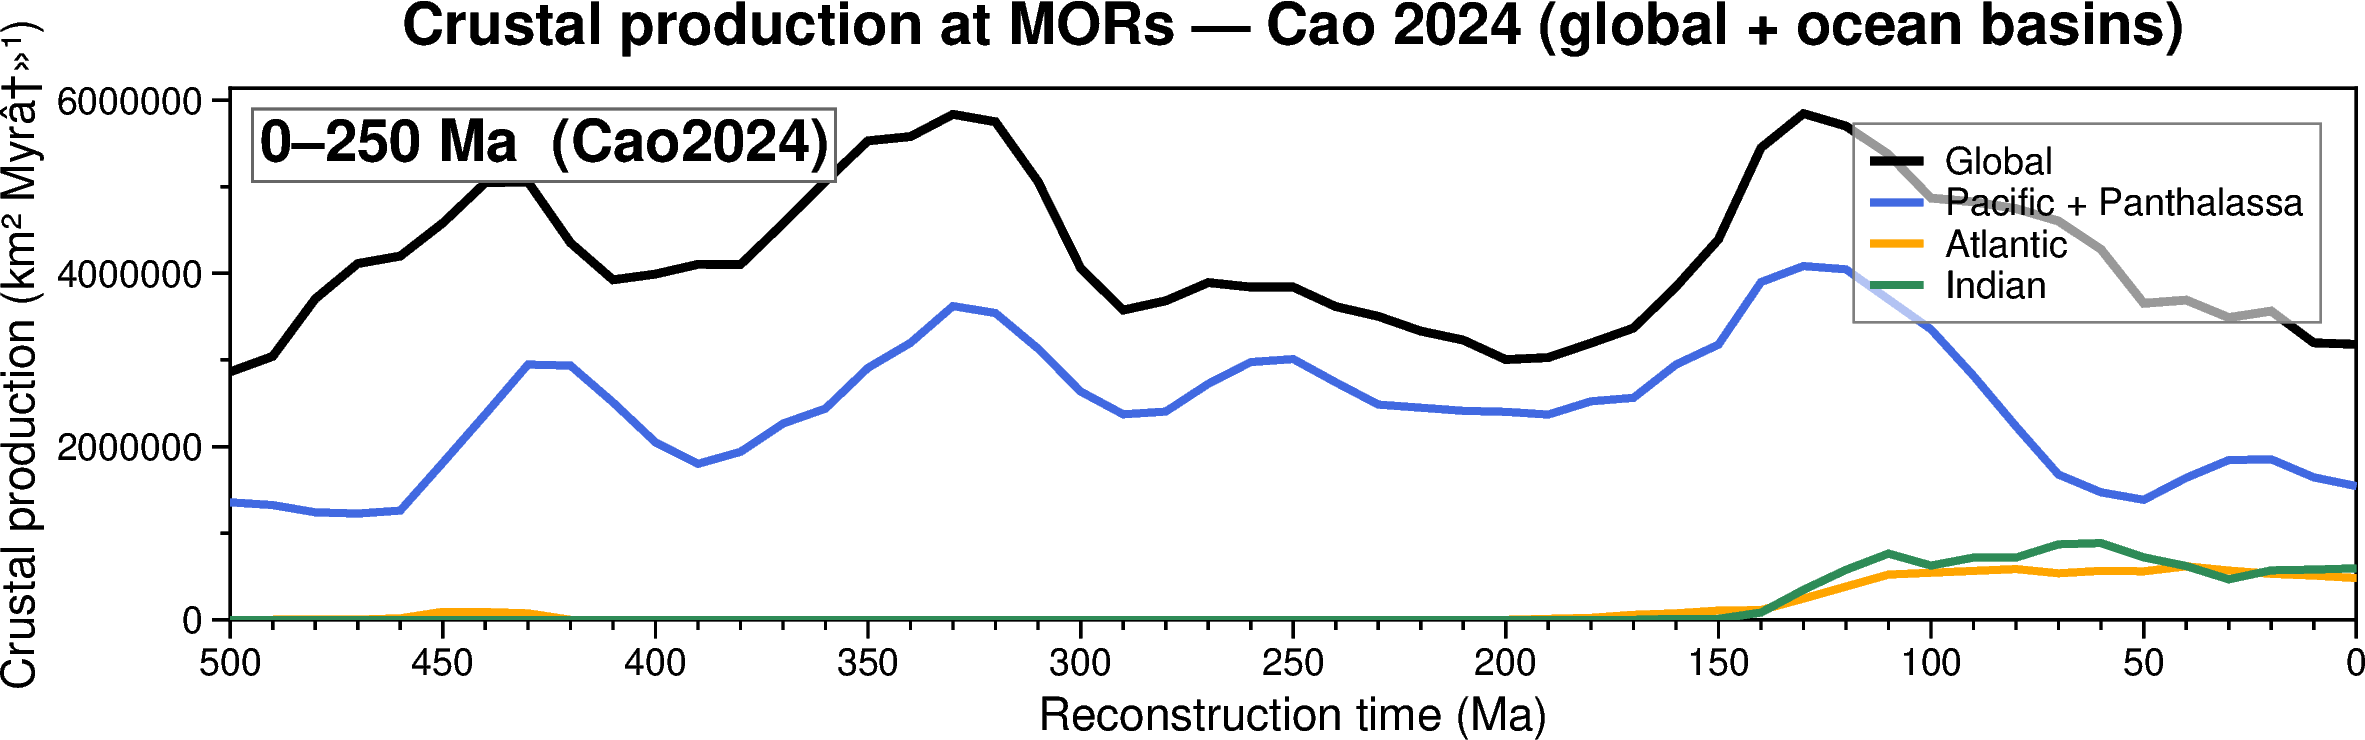

In [6]:
# Cell 5 — Plot 1: crustal production per basin
smoothed = cp.set_index("time").rolling(3, min_periods=1, center=True).mean()

# Fit y-axis to the data: for non-negative metrics anchor at 0 if any
# series touches zero (Atlantic/Indian start at 0 pre-rifting), otherwise
# pad both ends by 5 % of the range so the curves don't sit on the frame.
_y = smoothed[["prod_global", "prod_pacific", "prod_atlantic", "prod_indian"]].values
_y_lo, _y_hi = float(_y.min()), float(_y.max())
_pad = 0.05 * (_y_hi - _y_lo)
_y_lo = 0.0 if _y_lo < _pad else _y_lo - _pad
_y_hi += _pad

fig = pygmt.Figure()
fig.basemap(
    region=[TIME_MIN, TIME_MAX, _y_lo, _y_hi],
    projection="X-18c/4.5c",  # negative width \u2192 reversed x-axis; 4.5cm tall
    frame=["xaf+lReconstruction time (Ma)",
           "yaf+lCrustal production (km\u00b2 Myr\u207b\u00b9)",
           "WSrt+tCrustal production at MORs \u2014 Cao 2024 (global + ocean basins)"])

fig.plot(x=smoothed.index, y=smoothed["prod_global"],
         pen="2p,black",       label="Global")
fig.plot(x=smoothed.index, y=smoothed["prod_pacific"],
         pen="1.8p,royalblue", label="Pacific + Panthalassa")
fig.plot(x=smoothed.index, y=smoothed["prod_atlantic"],
         pen="1.8p,orange",    label="Atlantic")
fig.plot(x=smoothed.index, y=smoothed["prod_indian"],
         pen="1.8p,seagreen",  label="Indian")
fig.legend(position="JTR+jTR+o0.3c", box="+gwhite@40+p0.5p,gray50")
fig.text(text=f"0–250 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## Plot 2 — Total subduction-zone length (km)

Summed across every active trench segment in the Cao 2024 topology snapshot at each time step. A peak in this curve marks a time of dense global subduction (typical at supercontinent assembly + dispersal events); a trough marks intervals when only a few long arcs were active.

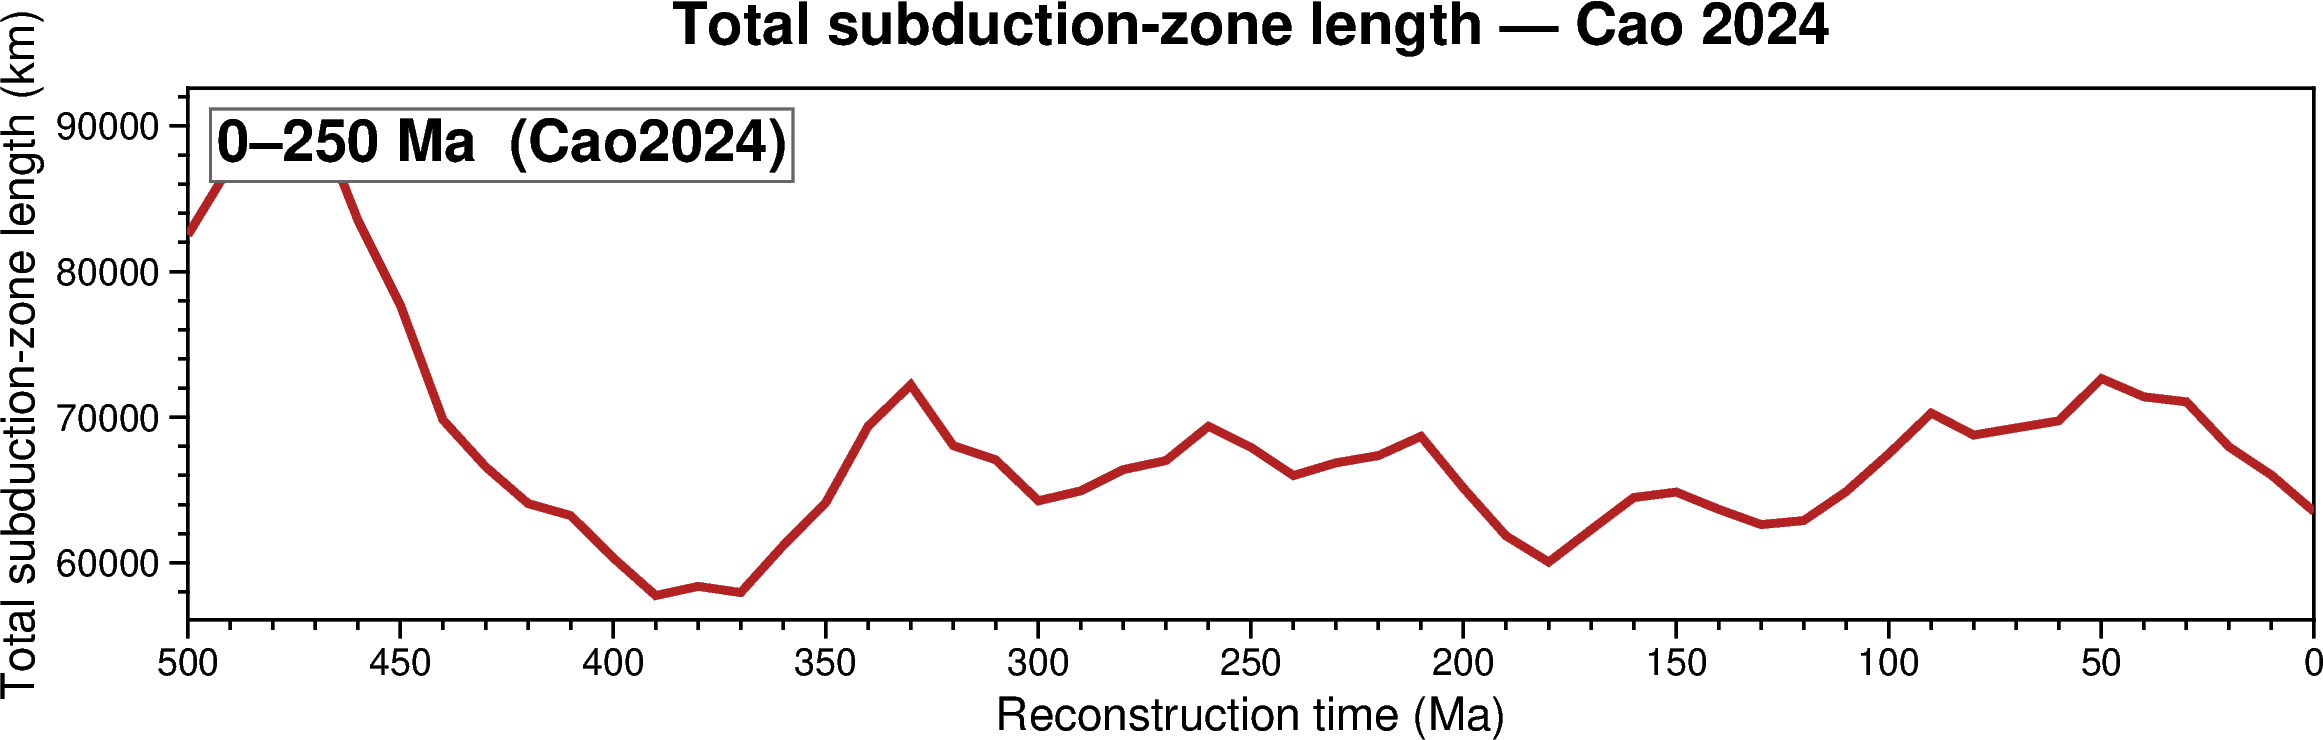

In [7]:
# Cell 6 — Plot 2: total subduction-zone length
_y    = smoothed["sub_length_km"].values
_y_lo, _y_hi = float(np.nanmin(_y)), float(np.nanmax(_y))
_pad  = 0.05 * (_y_hi - _y_lo)
_y_lo = max(0.0, _y_lo - _pad)
_y_hi += _pad

fig = pygmt.Figure()
fig.basemap(
    region=[TIME_MIN, TIME_MAX, _y_lo, _y_hi],
    projection="X-18c/4.5c",
    frame=["xaf+lReconstruction time (Ma)",
           "yaf+lTotal subduction-zone length (km)",
           "WSrt+tTotal subduction-zone length \u2014 Cao 2024"])
fig.plot(x=smoothed.index, y=smoothed["sub_length_km"],
         pen="2p,firebrick")
fig.text(text=f"0–250 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## Plot 3 — Number of modelled plates

Counts every resolved topological object (closed rigid plate boundaries + deforming networks) in the Cao 2024 model at each time. Rises are typically driven by ocean-basin fragmentation; falls are driven by plate amalgamation at supercontinent assembly.

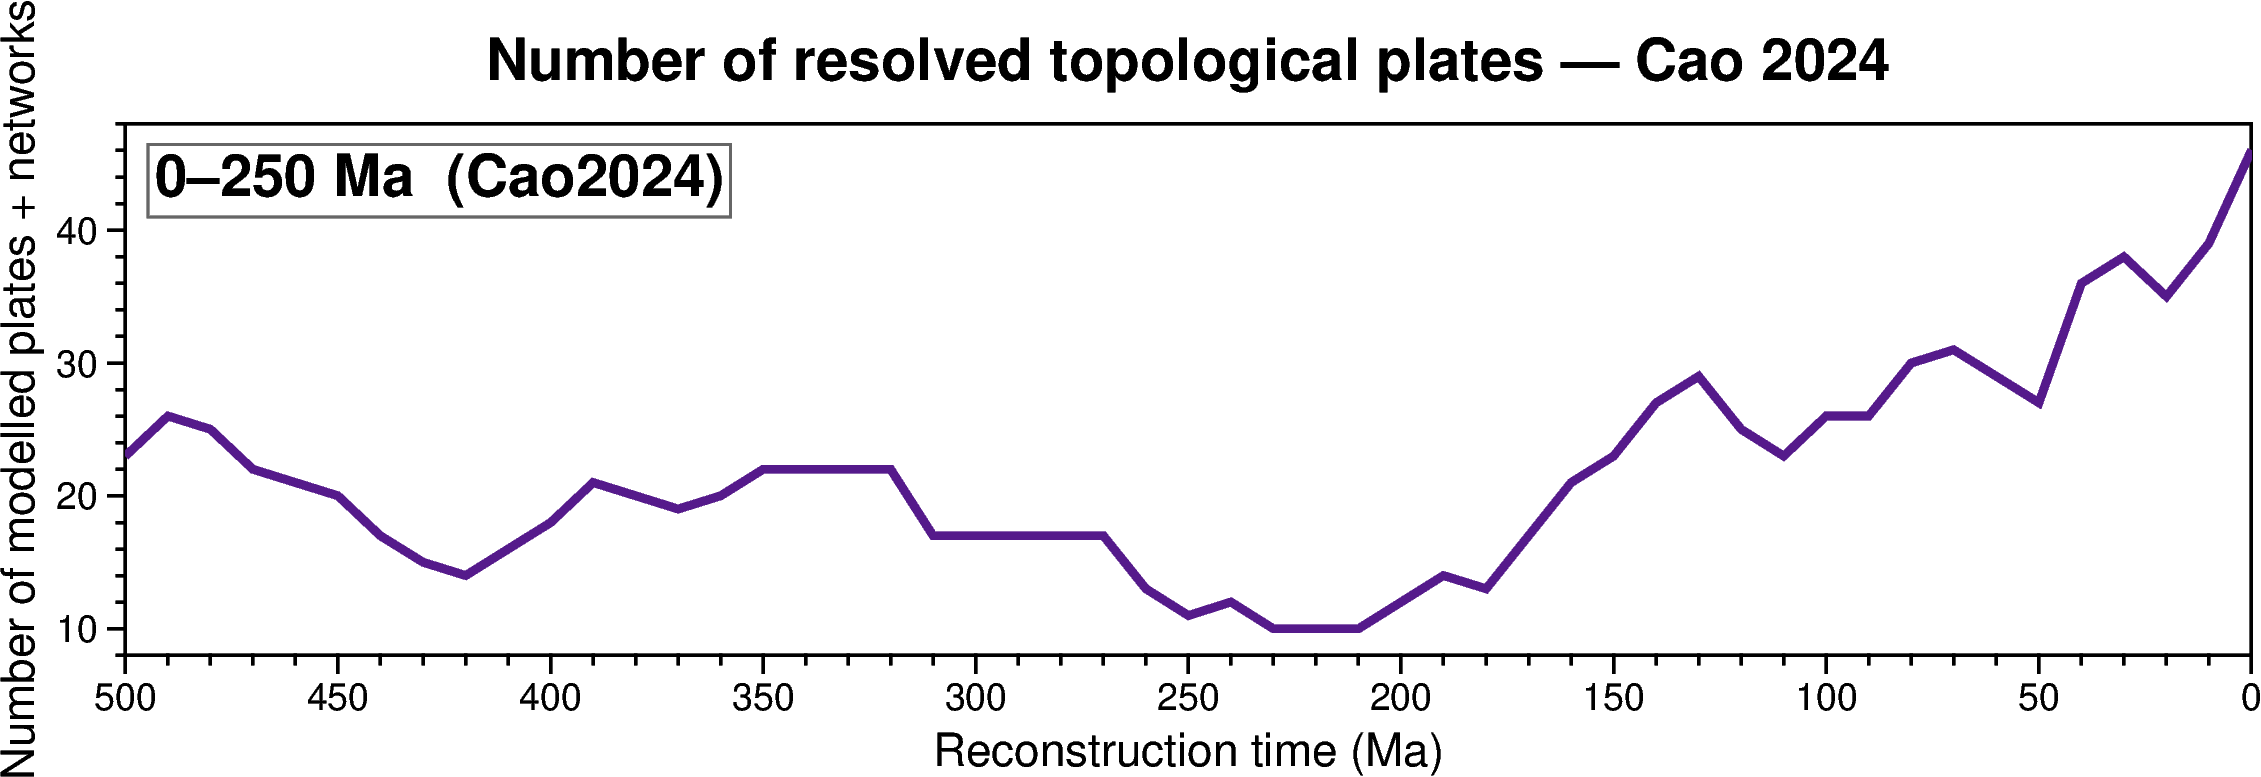

In [8]:
# Cell 7 — Plot 3: number of plates
_y    = cp["n_plates"].values
_y_lo, _y_hi = float(_y.min()), float(_y.max())
_pad  = max(2.0, 0.05 * (_y_hi - _y_lo))   # at least 2-plate padding
_y_lo = max(0.0, _y_lo - _pad)
_y_hi += _pad

fig = pygmt.Figure()
fig.basemap(
    region=[TIME_MIN, TIME_MAX, _y_lo, _y_hi],
    projection="X-18c/4.5c",
    frame=["xaf+lReconstruction time (Ma)",
           "yaf+lNumber of modelled plates + networks",
           "WSrt+tNumber of resolved topological plates \u2014 Cao 2024"])
fig.plot(x=cp["time"], y=cp["n_plates"],
         pen="2p,purple4")
fig.text(text=f"0–250 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## Plot 4 — Paleo-latitudes of North America, India, Australia

We reconstruct three representative present-day cratonic centroids (Müller/Cao plate IDs 101 = Laurentia, 501 = India, 801 = Australia) to each time step and plot the resulting paleo-latitudes. The 0° equator is shown as a dashed grey line for reference.

These curves are the kinematic signatures of:
- **North America's** Mesozoic–Cenozoic rotation and modest northward drift
- **India's** rapid northward migration from Gondwana (~150 Ma) culminating in the Eocene Asia collision
- **Australia's** post-rift northward drift from the Antarctic margin (~45 Ma onwards)

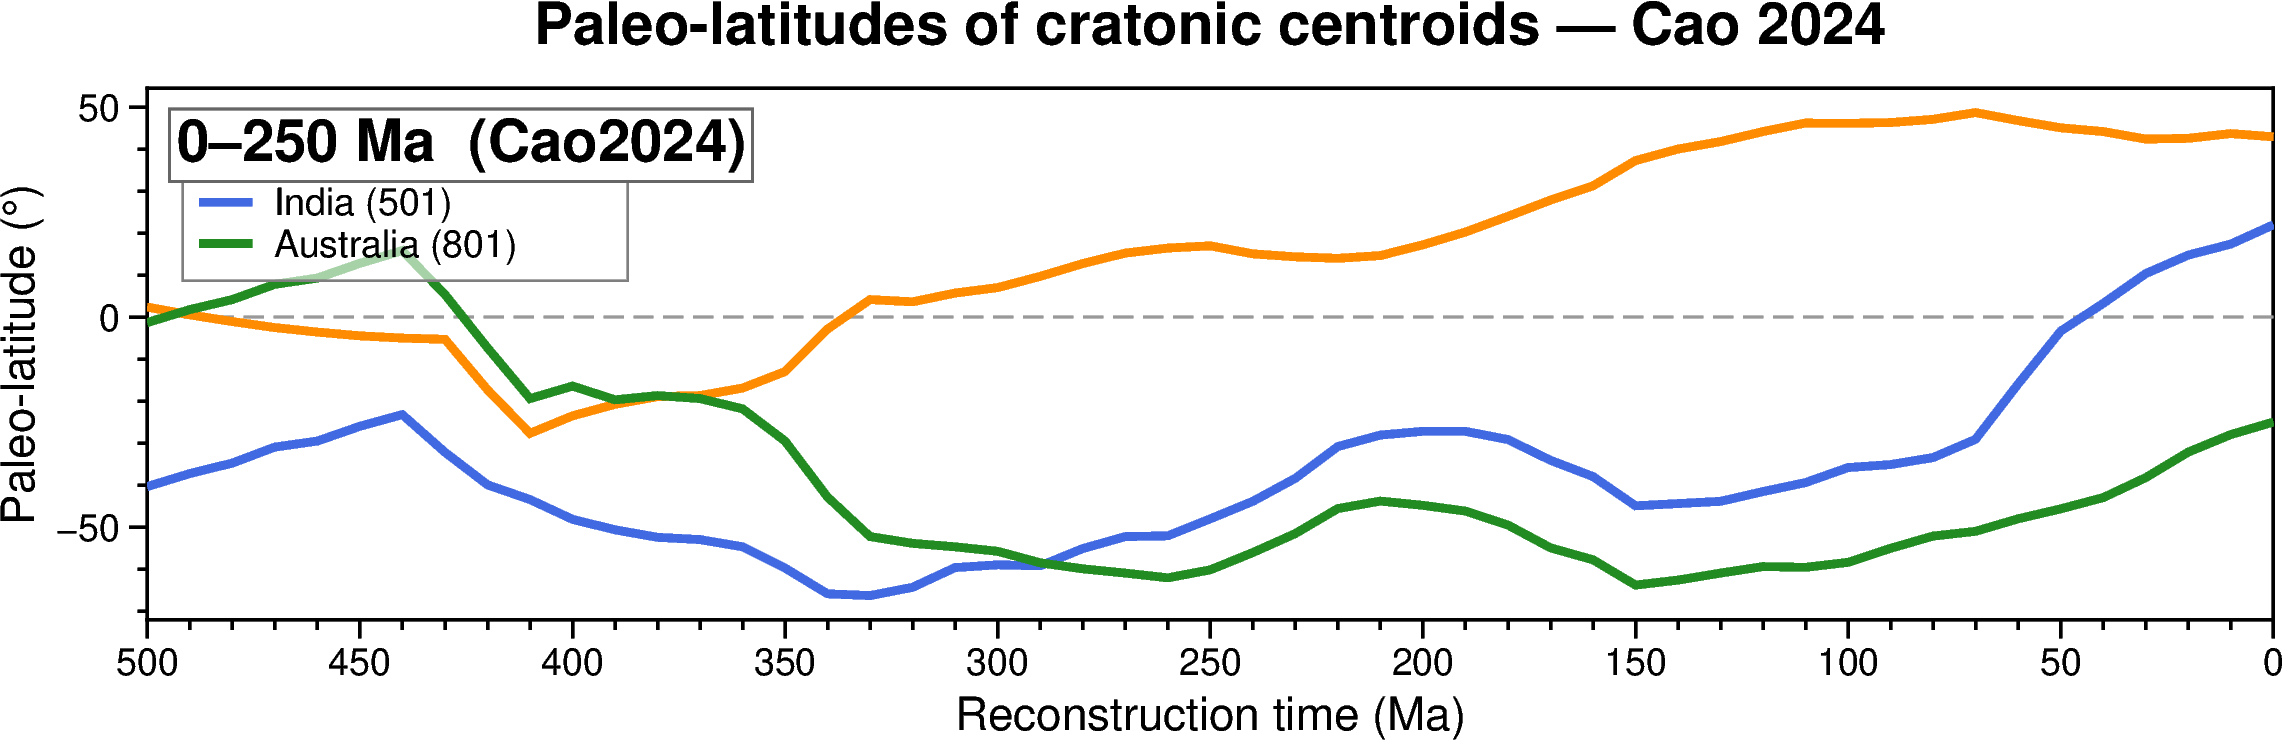

In [9]:
# Cell 8 — Plot 4: paleo-latitudes
_y = cp[["plat_NA", "plat_India", "plat_Aus"]].values
_y = _y[~np.isnan(_y)]
_y_lo, _y_hi = float(_y.min()), float(_y.max())
_pad = max(3.0, 0.05 * (_y_hi - _y_lo))
_y_lo -= _pad
_y_hi += _pad
# Make sure the equator (0\u00b0) is inside the range for visual anchoring
_y_lo = min(_y_lo, -2.0)
_y_hi = max(_y_hi, 2.0)

fig = pygmt.Figure()
fig.basemap(
    region=[TIME_MIN, TIME_MAX, _y_lo, _y_hi],
    projection="X-18c/4.5c",
    frame=["xaf+lReconstruction time (Ma)",
           "yaf+lPaleo-latitude (\u00b0)",
           "WSrt+tPaleo-latitudes of cratonic centroids \u2014 Cao 2024"])
# Equator reference
fig.plot(x=[TIME_MIN, TIME_MAX], y=[0, 0], pen="0.6p,gray60,--")
fig.plot(x=cp["time"], y=cp["plat_NA"],
         pen="2p,darkorange",  label="North America (101)")
fig.plot(x=cp["time"], y=cp["plat_India"],
         pen="2p,royalblue",   label="India (501)")
fig.plot(x=cp["time"], y=cp["plat_Aus"],
         pen="2p,forestgreen", label="Australia (801)")
fig.legend(position="JTL+jTL+o0.3c", box="+gwhite@40+p0.5p,gray50")
fig.text(text=f"0–250 Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

### How to read the four panels together

- **Pre-Pangea (≳ 200 Ma):** crustal production is concentrated in Panthalassa; subduction is correspondingly high; plate count is moderate; the three cratonic centroids are clustered in the southern hemisphere as part of Gondwana.
- **Pangea breakup (~200–80 Ma):** Atlantic and Indian basin curves rise from zero; new plates appear (plate-count tick up); India begins its rapid northward sprint while Australia and North America drift more sedately; subduction length rises with all the new active trenches.
- **Cenozoic (last ~65 Ma):** the four metrics stabilise toward modern values; India arrives in the northern hemisphere and decelerates after the Eocene Asian collision; subduction-zone length is at its modern global high.

Beyond ~410 Ma the Cao 2024 model is less well-constrained; treat the curves as first-order estimates only.

## Extend this

- **Larger time window.** Bump `TIME_MAX` to 1000 or 1800 (the Cao 2024 limit) to push the diagnostics into the Precambrian. Expect sparser data and more NaNs in the paleo-latitude columns as plate IDs become undefined.
- **More basins.** Add Tethys, Rheic, Asian basin plate-pair lists (full lists in the upstream Seton 2023 notebook).
- **More cratons.** Extend `CRATON_REFS` with e.g. East Antarctica (plate ID 802), Africa (701), Siberia (401), or South America (201) and re-run.
- **Different plate model.** Swap `Cao2024` for `Müller2022` or `Merdith2021`. Plate IDs carry over within the Müller / Cao family; for other model families either remap IDs by hand or switch to geographic bounding-box basin filtering (cf. T09).
- **Pair with T09.** T09 charts the *age* of crust at trenches (the consumption side); this notebook charts *production* at ridges and *subduction length* (the consumption side again, kinematically). Together they let you sketch a global oceanic-crustal-turnover mass balance through deep time.
- **Per-trench convergence-flux integration.** Multiply trench segment lengths by their convergence rates (also returned by `tessellate_subduction_zones`) to derive a subduction *volume* flux instead of a length.

## References

- Cao, X., Collins, A. S., Pisarevsky, S., Flament, N., Li, S., Hasterok, D., & Müller, R. D. (2024). A deep-time Phanerozoic to Proterozoic plate motion model at 1° resolution. *Earth System Science Data*, 16, 4007–4032. https://doi.org/10.5194/essd-16-4007-2024
- Chin, M., Mather, B. R., & Müller, R. D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Mather, B. R., Müller, R. D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N. M., Alfonso, C., Williams, S., Tetley, M., & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3–10. https://doi.org/10.1002/gdj3.185
- Seton, M., Williams, S. E., Domeier, M., Collins, A. S., & Sigloch, K. (2023). Deconstructing plate tectonic reconstructions. *Nature Reviews Earth & Environment*, 4, 185–204. https://doi.org/10.1038/s43017-022-00384-8 — concept source for the per-basin crustal-production filter and the diagnostic time-series ensemble reproduced here. Upstream code at <https://github.com/siwill22/Deconstructing-Plate-Tectonic-Reconstructions/blob/main/Figure6/CombinedTimeSeries.ipynb>.
- Tian, D., Uieda, L., Leong, W. J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J. F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W. H. F., & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems*, 20, 5556–5564. https://doi.org/10.1029/2019GC008515